In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.plot import show

sns.set_theme(style="whitegrid")

OUT_DIR = Path("eda_outputs")
OUT_DIR.mkdir(exist_ok=True, parents=True)

In [2]:
import fsspec

def extract_date_from_name(path: Path):
    m = re.search(r'(\d{4}-\d{2}-\d{2})', path.name)
    return pd.to_datetime(m.group(1)) if m else pd.NaT


def safe_stats(arr, valid_mask=None):
    if valid_mask is None:
        valid_mask = np.isfinite(arr)
    vals = arr[valid_mask]
    if vals.size == 0:
        return dict(count=0, min=np.nan, max=np.nan, mean=np.nan, std=np.nan)
    return dict(
        count=int(vals.size),
        min=float(np.nanmin(vals)),
        max=float(np.nanmax(vals)),
        mean=float(np.nanmean(vals)),
        std=float(np.nanstd(vals)),
    )


def read_firms_tif(path: str):
    with fsspec.open(path, 'rb') as f:
        with rasterio.open(f) as src:
            conf = src.read(1).astype("float32")
            t21 = src.read(2).astype("float32")
            label = src.read(3).astype("float32")
            profile = src.profile
            tags = src.tags()
            bounds = src.bounds
            crs = src.crs
            transform = src.transform
    return conf, t21, label, profile, tags, bounds, crs, transform

In [3]:
from google.colab import auth
auth.authenticate_user()

In [4]:
from google.cloud import storage

GCS_BUCKET_NAME = 'wildfire-detection-first'
GCS_PREFIX = 'firms_daily_geotiff/'

client = storage.Client()

In [5]:
gcs_files = []
bucket = client.bucket(GCS_BUCKET_NAME)

# List blobs (files) under the specified prefix
for blob in bucket.list_blobs(prefix=GCS_PREFIX):
    # Only include .tif or .tiff files and exclude directories (blobs ending with /)
    if (blob.name.endswith('.tif') or blob.name.endswith('.tiff')) and not blob.name.endswith('/'):
        gcs_files.append(f"gs://{GCS_BUCKET_NAME}/{blob.name}")

print(f"Found {len(gcs_files)} GeoTIFFs in GCS")

# The extract_date_from_name function expects a pathlib.Path object or a string with a filename
# For GCS paths, we can adapt it to work with the string directly or extract the filename
# For simplicity, let's adapt extract_date_from_name to take a full GCS path string
# We need to make sure the date extraction works correctly from the full GCS path string

# Let's redefine extract_date_from_name to handle string paths directly for GCS
def extract_date_from_gcs_name(gcs_path: str):
    # Extract just the filename part from the GCS path
    filename = gcs_path.split('/')[-1]
    m = re.search(r'(\d{4}-\d{2}-\d{2})', filename)
    return pd.to_datetime(m.group(1)) if m else pd.NaT

gcs_file_df = pd.DataFrame({
    "path": gcs_files,
    "date": [extract_date_from_gcs_name(p) for p in gcs_files]
}).sort_values("date")

Found 3642 GeoTIFFs in GCS


In [6]:
display(gcs_file_df.head())


,path,date
0,gs://wildfire-detection-first/firms_daily_geot...,2016-01-01
1,gs://wildfire-detection-first/firms_daily_geot...,2016-01-02
2,gs://wildfire-detection-first/firms_daily_geot...,2016-01-03
3,gs://wildfire-detection-first/firms_daily_geot...,2016-01-04
4,gs://wildfire-detection-first/firms_daily_geot...,2016-01-05


In [7]:
# !pip install gcsfs

rows = []

for p, date in zip(gcs_file_df["path"], gcs_file_df["date"]):
    conf, t21, label, profile, tags, bounds, crs, transform = read_firms_tif(p)

    valid_mask = np.isfinite(label)
    positive_mask = (label > 0) & valid_mask

    n_valid = int(valid_mask.sum())
    n_positive = int(positive_mask.sum())
    positive_fraction = (n_positive / n_valid) if n_valid else np.nan
    has_fire = int(n_positive > 0)

    conf_stats = safe_stats(conf, np.isfinite(conf))
    t21_stats = safe_stats(t21, np.isfinite(t21))

    rows.append({
        "date": date,
        "file": p,
        "height": profile["height"],
        "width": profile["width"],
        "dtype": profile["dtype"],
        "crs": str(crs),
        "n_valid_pixels": n_valid,
        "n_positive_pixels": n_positive,
        "positive_fraction": positive_fraction,
        "has_fire": has_fire,
        "confidence_min": conf_stats["min"],
        "confidence_max": conf_stats["max"],
        "confidence_mean": conf_stats["mean"],
        "t21_min": t21_stats["min"],
        "t21_max": t21_stats["max"],
        "t21_mean": t21_stats["mean"],
    })

summary = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
summary.to_csv(OUT_DIR / "firms_daily_summary.csv", index=False)
summary.head()

,date,file,height,width,dtype,crs,n_valid_pixels,n_positive_pixels,positive_fraction,has_fire,confidence_min,confidence_max,confidence_mean,t21_min,t21_max,t21_mean
0,2016-01-01,gs://wildfire-detection-first/firms_daily_geot...,1056,1153,float32,EPSG:4326,0,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-02,gs://wildfire-detection-first/firms_daily_geot...,1056,1153,float32,EPSG:4326,0,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-03,gs://wildfire-detection-first/firms_daily_geot...,1056,1153,float32,EPSG:4326,0,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-04,gs://wildfire-detection-first/firms_daily_geot...,1056,1153,float32,EPSG:4326,5,5,1.0,1,43.0,43.0,43.0,310.799988,310.799988,310.799988
4,2016-01-05,gs://wildfire-detection-first/firms_daily_geot...,1056,1153,float32,EPSG:4326,2,2,1.0,1,45.0,45.0,45.0,311.000000,311.000000,311.000000


In [8]:
summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3642 entries, 0 to 3641
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               3642 non-null   datetime64[ns]
 1   file               3642 non-null   object        
 2   height             3642 non-null   int64         
 3   width              3642 non-null   int64         
 4   dtype              3642 non-null   object        
 5   crs                3642 non-null   object        
 6   n_valid_pixels     3642 non-null   int64         
 7   n_positive_pixels  3642 non-null   int64         
 8   positive_fraction  3133 non-null   float64       
 9   has_fire           3642 non-null   int64         
 10  confidence_min     3131 non-null   float64       
 11  confidence_max     3131 non-null   float64       
 12  confidence_mean    3131 non-null   float64       
 13  t21_min            3133 non-null   float64       
 14  t21_max 

In [9]:
summary[[
    "date", "file", "n_valid_pixels", "n_positive_pixels",
    "positive_fraction", "confidence_mean", "t21_mean"
]].head()

summary.describe(include="all")

# date: This column represents the date of the satellite imagery, extracted directly from the filename of the GeoTIFF file. It indicates the specific day for which the fire detection data is relevant.
# file: This is the full GCS path to the original GeoTIFF file from which the data for that row was processed.
# height: This indicates the height (number of rows) of the raster image in pixels, as specified in the GeoTIFF's profile.
# width: This indicates the width (number of columns) of the raster image in pixels, as specified in the GeoTIFF's profile.
# dtype: This is the data type of the pixel values within the GeoTIFF bands (e.g., float32).
# crs: This stands for Coordinate Reference System. It specifies the geographical coordinate system used by the GeoTIFF (e.g., EPSG:4326 for WGS 84 latitude/longitude).
# n_valid_pixels: This is the total number of valid (non-NaN, or finite) pixels in the label band of the GeoTIFF for a given day. These are the pixels that were successfully processed.
# n_positive_pixels: This is the count of 'positive' pixels detected. A pixel is considered 'positive' if its value in the label band is greater than 0, indicating the presence of a fire or a high-confidence fire-related feature.
# positive_fraction: This is the proportion of positive pixels relative to the total number of valid pixels (n_positive_pixels / n_valid_pixels). It tells you how much of the valid area on a given day showed fire activity.
# has_fire: A binary indicator (1 or 0) that signifies whether at least one positive pixel was detected on that day. 1 means there was fire, 0 means no fire.
# confidence_min: The minimum confidence value observed among the valid pixels in the conf band for that day.
# confidence_max: The maximum confidence value observed among the valid pixels in the conf band for that day.
# confidence_mean: The average confidence value observed among the valid pixels in the conf band for that day. The conf band typically represents the fire detection confidence.
# t21_min: The minimum T21 (thermal band 21) value observed among the valid pixels in the t21 band for that day.
# t21_max: The maximum T21 value observed among the valid pixels in the t21 band for that day.
# t21_mean: The average T21 value observed among the valid pixels in the t21 band for that day. The t21 band likely refers to a specific thermal infrared channel that helps in fire detection.

,date,file,height,width,dtype,crs,n_valid_pixels,n_positive_pixels,positive_fraction,has_fire,confidence_min,confidence_max,confidence_mean,t21_min,t21_max,t21_mean
count,3642,3642,3642.0,3642.0,3642,3642,3642.000000,3642.000000,3133.0,3642.000000,3131.000000,3131.000000,3131.000000,3133.000000,3133.000000,3133.000000
unique,NaN,3642,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,gs://wildfire-detection-first/firms_daily_geot...,NaN,NaN,float32,EPSG:4326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,3642,3642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2021-01-03 21:23:25.601318144,NaN,1056.0,1153.0,NaN,NaN,193.815761,193.815761,1.0,0.860242,34.599489,88.408815,68.644309,306.704654,363.059860,325.252075
min,2016-01-01 00:00:00,NaN,1056.0,1153.0,NaN,NaN,0.000000,0.000000,1.0,0.000000,1.000000,9.000000,9.000000,300.000000,300.059998,300.059998
25%,2018-07-10 06:00:00,NaN,1056.0,1153.0,NaN,NaN,21.250000,21.250000,1.0,1.000000,21.000000,81.000000,61.803846,300.899994,327.200012,314.098541
50%,2021-01-05 12:00:00,NaN,1056.0,1153.0,NaN,NaN,78.000000,78.000000,1.0,1.000000,33.000000,94.000000,68.674629,303.700012,345.000000,322.539368
75%,2023-07-04 18:00:00,NaN,1056.0,1153.0,NaN,NaN,187.000000,187.000000,1.0,1.000000,46.000000,100.000000,76.432911,310.269989,381.700012,332.735779
max,2025-12-31 00:00:00,NaN,1056.0,1153.0,NaN,NaN,7340.000000,7340.000000,1.0,1.000000,100.000000,100.000000,100.000000,396.290009,509.500000,417.066681


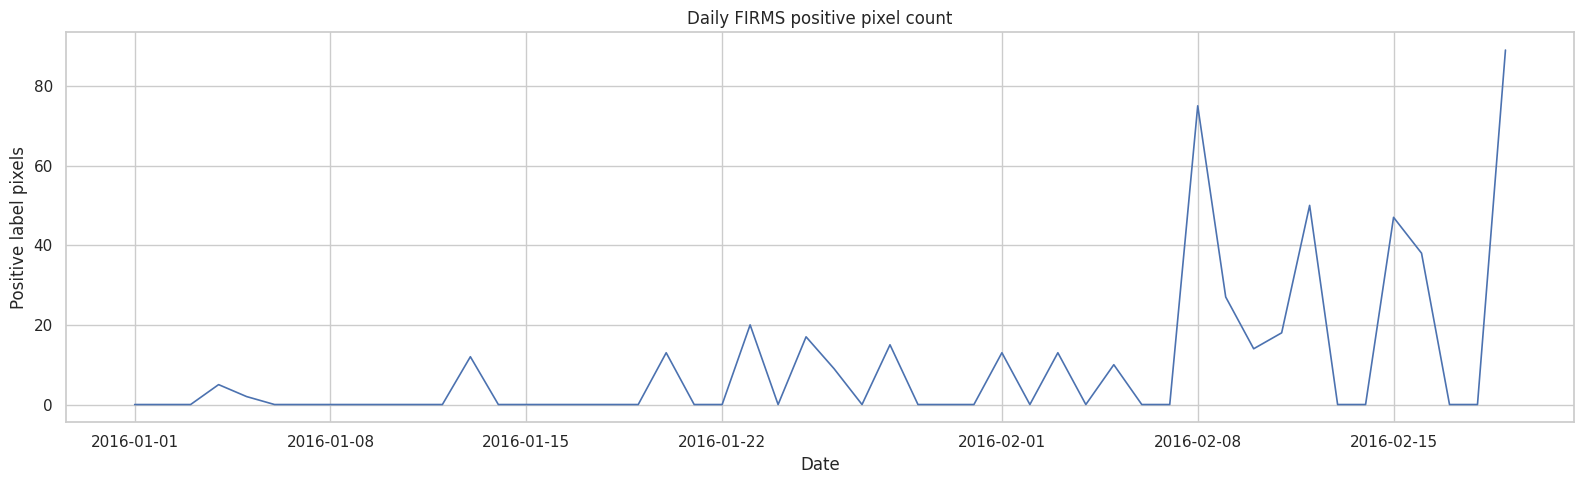

In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(summary["date"], summary["n_positive_pixels"], linewidth=1.2)
plt.title("Daily FIRMS positive pixel count")
plt.xlabel("Date")
plt.ylabel("Positive label pixels")
plt.tight_layout()
plt.savefig(OUT_DIR / "daily_positive_pixels.png", dpi=160)
plt.show()

### Monthly aggregation

In [19]:
monthly_summary = (
    summary.assign(month=summary["date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        days=("date", "count"),
        total_positive_pixels=("n_positive_pixels", "sum"),
        mean_positive_fraction=("positive_fraction", "mean")
    )
)
monthly_summary.to_csv(OUT_DIR / "firms_monthly_summary.csv", index=False)
monthly_summary.head()

,month,days,total_positive_pixels,mean_positive_fraction
0,2016-01-01,31,93,1.0
1,2016-02-01,29,615,1.0
2,2016-03-01,31,757,1.0
3,2016-04-01,30,748,1.0
4,2016-05-01,31,1171,1.0


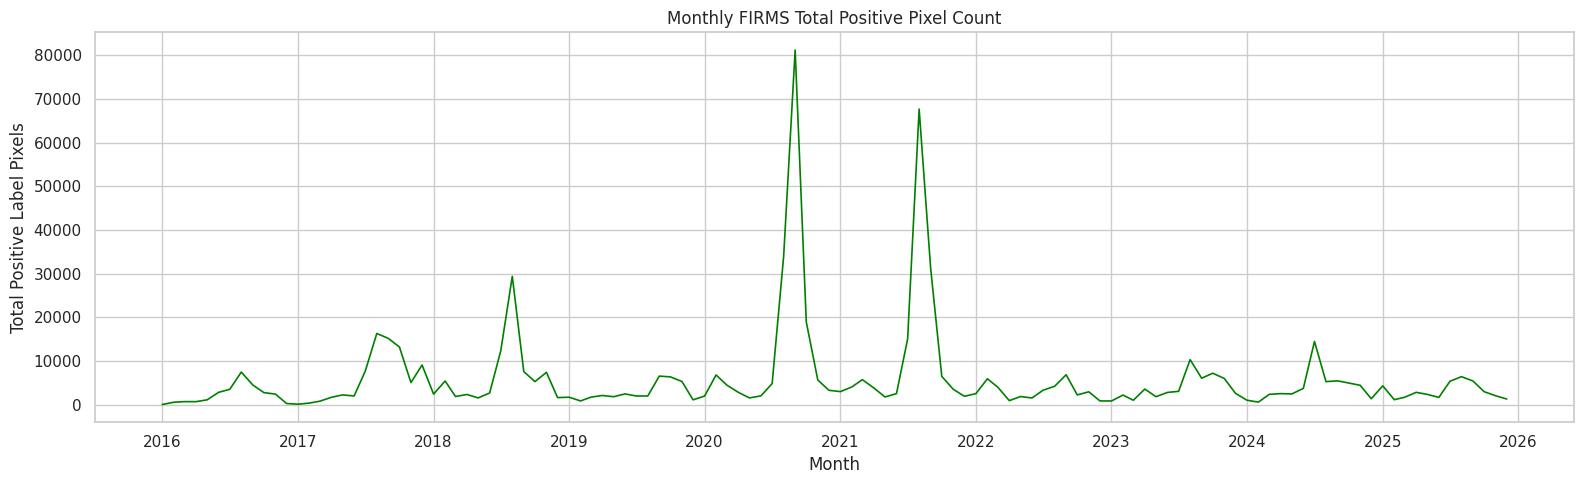

In [11]:
plt.figure(figsize=(16, 5))
plt.plot(monthly_summary["month"], monthly_summary["total_positive_pixels"], linewidth=1.2, color="green")
plt.title("Monthly FIRMS Total Positive Pixel Count")
plt.xlabel("Month")
plt.ylabel("Total Positive Label Pixels")
plt.tight_layout()
plt.savefig(OUT_DIR / "monthly_total_positive_pixels.png", dpi=160)
plt.show()

In [21]:
yearly = (
    summary.assign(year=summary["date"].dt.to_period("Y").dt.to_timestamp())
    .groupby("year", as_index=False)
    .agg(
        days=("date", "count"),
        total_positive_pixels=("n_positive_pixels", "sum"),
    )
)
yearly.to_csv(OUT_DIR / "firms_yearly_summary.csv", index=False)
yearly.head()

,year,days,total_positive_pixels
0,2016-01-01,366,27533
1,2017-01-01,356,74365
2,2018-01-01,363,80460
3,2019-01-01,365,34658
4,2020-01-01,366,167987


### Distribution plots

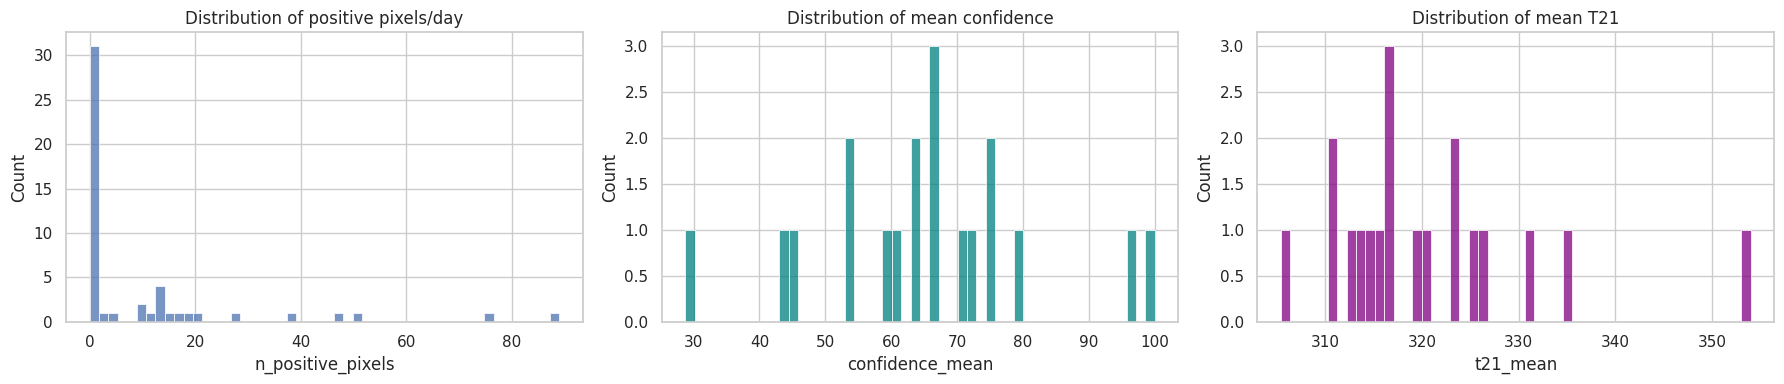

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(summary["n_positive_pixels"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of positive pixels/day")

sns.histplot(summary["confidence_mean"].dropna(), bins=50, ax=axes[1], color="teal")
axes[1].set_title("Distribution of mean confidence")

sns.histplot(summary["t21_mean"].dropna(), bins=50, ax=axes[2], color="purple")
axes[2].set_title("Distribution of mean T21")

plt.tight_layout()
plt.savefig(OUT_DIR / "distribution_plots.png", dpi=160)
plt.show()

### Spatial hotspot frequency map

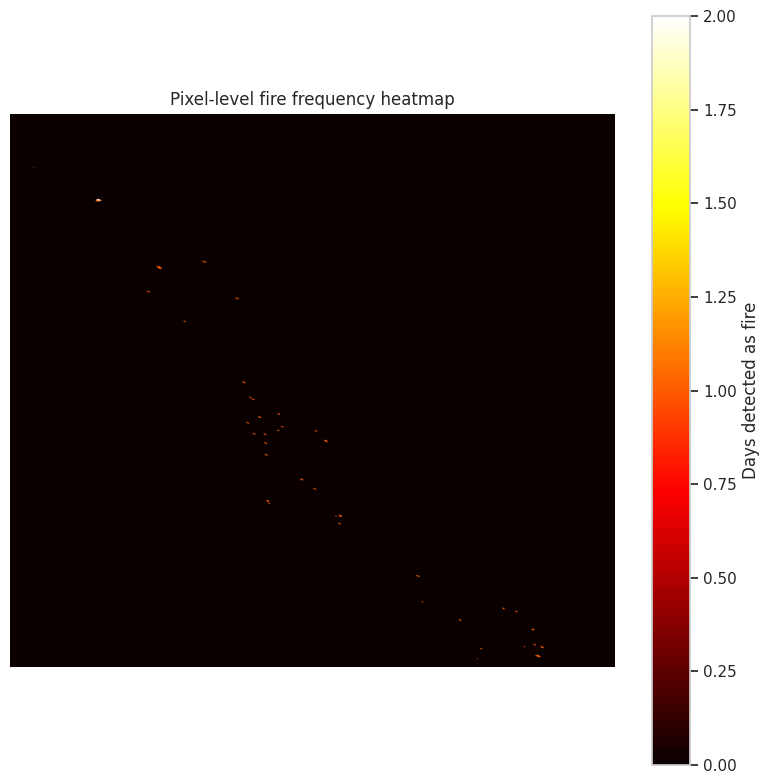

In [ ]:
first_conf, first_t21, first_label, profile, tags, bounds, crs, transform = read_firms_tif(gcs_file_df.iloc[0]["path"])
heat = np.zeros_like(first_label, dtype=np.float32)

for p in gcs_file_df["path"]:
    _, _, label, *_ = read_firms_tif(p)
    heat += (np.isfinite(label) & (label > 0)).astype(np.float32)

plt.figure(figsize=(8, 8))
plt.imshow(heat, cmap="hot")
plt.title("Pixel-level fire frequency heatmap")
plt.axis("off")
plt.colorbar(label="Days detected as fire")
plt.tight_layout()
plt.savefig(OUT_DIR / "pixel_fire_frequency_heatmap.png", dpi=160)
plt.show()

### Save top fire days table

In [22]:
top_days = summary.sort_values("n_positive_pixels", ascending=False).head(30)
top_days.to_csv(OUT_DIR / "top_30_fire_days.csv", index=False)
top_days[["date", "file", "n_positive_pixels", "positive_fraction"]]

,date,file,n_positive_pixels,positive_fraction
1702,2020-09-09,gs://wildfire-detection-first/firms_daily_geot...,7340,1.0
1701,2020-09-08,gs://wildfire-detection-first/firms_daily_geot...,5337,1.0
1682,2020-08-20,gs://wildfire-detection-first/firms_daily_geot...,5045,1.0
1703,2020-09-10,gs://wildfire-detection-first/firms_daily_geot...,4435,1.0
1681,2020-08-19,gs://wildfire-detection-first/firms_daily_geot...,4145,1.0
1707,2020-09-14,gs://wildfire-detection-first/firms_daily_geot...,3979,1.0
1706,2020-09-13,gs://wildfire-detection-first/firms_daily_geot...,3815,1.0
1705,2020-09-12,gs://wildfire-detection-first/firms_daily_geot...,3667,1.0
1700,2020-09-07,gs://wildfire-detection-first/firms_daily_geot...,3548,1.0
2044,2021-08-17,gs://wildfire-detection-first/firms_daily_geot...,3501,1.0
